### Importing libraries and loading data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── CSV larni yuklash ──────────────────────────────────────
df = pd.read_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_vacancies.csv")
df_skills = pd.read_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_skills.csv")
df_companies = pd.read_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_companies.csv")
df_vs = pd.read_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_vacancy_skill.csv")
df_locations = pd.read_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_locations.csv")  


# ── Sana formatini to'g'irlash ─────────────────────────────
df["publish_date"] = pd.to_datetime(df["publish_date"], errors="coerce")

print("✅ Ma'lumotlar yuklandi!")
print(f"   Vacancies : {len(df)}")
print(f"   Companies : {len(df_companies)}")
print(f"   Skills    : {len(df_skills)}")
print(f"   Locations : {len(df_locations)}")
print(f"   Links     : {len(df_vs)}")

df.head()

✅ Ma'lumotlar yuklandi!
   Vacancies : 98
   Companies : 59
   Skills    : 269
   Locations : 2
   Links     : 528


,h_id,title,position,category,publish_date,company,skills,country,location,min_salary,max_salary,currency
0,130423250,GIS and RS Analyst,GIS and RS Analyst,Геодезист,2026-03-09,Национальный комитет Республики Узбекистан по ...,gis;qgis,Uzbekistan,Ташкент,1500.0,2000.0,USD
1,130834161,Process Analyst,Process Analyst,Бизнес-аналитик,2026-03-08,CIVITTA CA,NaN,Uzbekistan,Ташкент,NaN,2250.0,EUR
2,130937811,Senior Data Analyst,Senior Data Analyst,"BI-аналитик, аналитик данных",2026-03-06,АО СО INSON,python;scipy;dwh;sql;big data;data analysis;da...,Uzbekistan,Ташкент,NaN,NaN,NaN
3,127408968,Data Science специалист,Data Science специалист,"BI-аналитик, аналитик данных",2026-03-08,FlexSoft,sql;исследовательский анализ данных;mlflow;биз...,Uzbekistan,Ташкент,NaN,NaN,NaN
4,130196287,Data Scientist,Data Scientist,Дата-сайентист,2026-03-07,PAYNET,NaN,Uzbekistan,Ташкент,NaN,NaN,NaN


### General Info

In [2]:
print("=" * 50)
print("UMUMIY MA'LUMOT")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("BO'SH QIYMATLAR (NULL)")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("MAOSH MA'LUMOTLARI")
print("=" * 50)
print(f"Maosh ko'rsatilgan  : {df['min_salary'].notna().sum()} ta")
print(f"Maosh ko'rsatilmagan: {df['min_salary'].isna().sum()} ta")
print(f"\nValyutalar: {df['currency'].value_counts().to_dict()}")

print("\n" + "=" * 50)
print("KATEGORIYALAR")
print("=" * 50)
print(df['category'].value_counts())

UMUMIY MA'LUMOT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   h_id          98 non-null     int64         
 1   title         98 non-null     object        
 2   position      98 non-null     object        
 3   category      98 non-null     object        
 4   publish_date  98 non-null     datetime64[ns]
 5   company       98 non-null     object        
 6   skills        59 non-null     object        
 7   country       98 non-null     object        
 8   location      98 non-null     object        
 9   min_salary    14 non-null     float64       
 10  max_salary    16 non-null     float64       
 11  currency      17 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 9.3+ KB
None

BO'SH QIYMATLAR (NULL)
h_id             0
title            0
position         0
category      

### Data cleaning

In [3]:
# ── 1. Nusxa olamiz (asl ma'lumot saqlansin) ──────────────
df_clean = df.copy()

# ── 2. Skills: bo'shlarni "Not specified" bilan to'ldiramiz
df_clean["skills"] = df_clean["skills"].fillna("not specified")

# ── 3. Maosh: bo'sh bo'lsa NaN qoladi (o'chirmaymiz — Power BI o'zi filtrlab oladi)
# Faqat USD ga normalize qilamiz (taxminiy kurslar)
UZS_RATE = 12800
EUR_RATE = 1.08

def to_usd(row, col):
    val = row[col]
    if pd.isna(val):
        return None
    if row["currency"] == "USD":
        return round(val, 2)
    elif row["currency"] == "UZS":
        return round(val / UZS_RATE, 2)
    elif row["currency"] == "EUR":
        return round(val * EUR_RATE, 2)
    return None

df_clean["min_salary_usd"] = df_clean.apply(lambda r: to_usd(r, "min_salary"), axis=1)
df_clean["max_salary_usd"] = df_clean.apply(lambda r: to_usd(r, "max_salary"), axis=1)

# ── 4. Category: Ruscha → Inglizcha mapping ────────────────
category_map = {
    "BI-аналитик, аналитик данных"                    : "Data / BI Analyst",
    "Дата-сайентист"                                  : "Data Scientist",
    "Бизнес-аналитик"                                 : "Business Analyst",
    "Другое"                                          : "Other",
    "Аналитик"                                        : "Analyst",
    "Маркетолог-аналитик"                             : "Marketing Analyst",
    "Системный аналитик"                              : "System Analyst",
    "Руководитель отдела аналитики"                   : "Head of Analytics",
    "Программист, разработчик"                        : "Developer",
    "Менеджер продукта"                               : "Product Manager",
    "Финансовый аналитик, инвестиционный аналитик"    : "Financial Analyst",
    "Руководитель отдела маркетинга и рекламы"        : "Head of Marketing",
    "Руководитель проектов"                           : "Project Manager",
    "Геодезист"                                       : "Other",
    "Менеджер по маркетингу, интернет-маркетолог"     : "Marketing Manager",
    "Продуктовый аналитик"                            : "Product Analyst",
    "Кредитный специалист"                            : "Credit Specialist",
    "Руководитель группы разработки"                  : "Dev Team Lead",
    "Руководитель отдела продаж"                      : "Head of Sales",
    "Технический директор (CTO)"                     : "CTO",
    "Руководитель отдела персонала"                   : "HR Manager",
    "Технический писатель"                            : "Technical Writer",
    "Директор по информационным технологиям (CIO)"    : "CIO",
    "Сетевой инженер"                                 : "Network Engineer",
    "Координатор отдела продаж"                       : "Sales Coordinator",
    "Системный администратор"                         : "System Admin",
    "Специалист по кадрам"                            : "HR Specialist",
    "Фармацевт-провизор"                              : "Other",
    "Комплаенс-менеджер"                              : "Compliance Manager",
    "Менеджер по работе с партнерами"                 : "Partnership Manager",
}
df_clean["category_en"] = df_clean["category"].map(category_map).fillna("Other")

# ── 5. Location: bo'sh → "Tashkent" (97% Uzbekiston vacancies Tashkent)
df_clean["location"] = df_clean["location"].replace("", "Tashkent").fillna("Tashkent")

# ── 6. Salary range ustuni (Power BI tooltip uchun)
df_clean["salary_range_usd"] = df_clean.apply(
    lambda r: f"${r['min_salary_usd']:.0f} – ${r['max_salary_usd']:.0f}"
    if pd.notna(r["min_salary_usd"]) and pd.notna(r["max_salary_usd"])
    else "Not disclosed", axis=1
)

# ── Natija ─────────────────────────────────────────────────
print("✅ Cleaning tugadi!")
print(f"\nYangi ustunlar: min_salary_usd, max_salary_usd, category_en, salary_range_usd")
print(f"\nMaosh ko'rsatilgan (USD): {df_clean['min_salary_usd'].notna().sum()} ta")
print(f"\nKategoriyalar (EN):\n{df_clean['category_en'].value_counts()}")

df_clean.head()

✅ Cleaning tugadi!

Yangi ustunlar: min_salary_usd, max_salary_usd, category_en, salary_range_usd

Maosh ko'rsatilgan (USD): 14 ta

Kategoriyalar (EN):
category_en
Data / BI Analyst      23
Data Scientist         10
Other                   9
Business Analyst        9
Analyst                 5
Marketing Analyst       4
Product Manager         3
Head of Analytics       3
Developer               3
System Analyst          3
Financial Analyst       3
Head of Marketing       2
Project Manager         2
Product Analyst         2
Marketing Manager       2
Credit Specialist       2
Dev Team Lead           2
Head of Sales           1
CTO                     1
HR Manager              1
Technical Writer        1
CIO                     1
Network Engineer        1
Sales Coordinator       1
System Admin            1
HR Specialist           1
Compliance Manager      1
Partnership Manager     1
Name: count, dtype: int64


,h_id,title,position,category,publish_date,company,skills,country,location,min_salary,max_salary,currency,min_salary_usd,max_salary_usd,category_en,salary_range_usd
0,130423250,GIS and RS Analyst,GIS and RS Analyst,Геодезист,2026-03-09,Национальный комитет Республики Узбекистан по ...,gis;qgis,Uzbekistan,Ташкент,1500.0,2000.0,USD,1500.0,2000.0,Other,$1500 – $2000
1,130834161,Process Analyst,Process Analyst,Бизнес-аналитик,2026-03-08,CIVITTA CA,not specified,Uzbekistan,Ташкент,NaN,2250.0,EUR,NaN,2430.0,Business Analyst,Not disclosed
2,130937811,Senior Data Analyst,Senior Data Analyst,"BI-аналитик, аналитик данных",2026-03-06,АО СО INSON,python;scipy;dwh;sql;big data;data analysis;da...,Uzbekistan,Ташкент,NaN,NaN,NaN,NaN,NaN,Data / BI Analyst,Not disclosed
3,127408968,Data Science специалист,Data Science специалист,"BI-аналитик, аналитик данных",2026-03-08,FlexSoft,sql;исследовательский анализ данных;mlflow;биз...,Uzbekistan,Ташкент,NaN,NaN,NaN,NaN,NaN,Data / BI Analyst,Not disclosed
4,130196287,Data Scientist,Data Scientist,Дата-сайентист,2026-03-07,PAYNET,not specified,Uzbekistan,Ташкент,NaN,NaN,NaN,NaN,NaN,Data Scientist,Not disclosed


### Location tozalash

In [4]:
# ── Location: Ruscha → Inglizcha ──────────────────────────
location_map = {
    "Ташкент"    : "Tashkent",
    "Самарканд"  : "Samarkand",
    "Бухара"     : "Bukhara",
    "Наманган"   : "Namangan",
    "Андижан"    : "Andijan",
    "Фергана"    : "Fergana",
    ""           : "Tashkent",
}
df_clean["location"] = df_clean["location"].map(location_map).fillna(df_clean["location"])
df_clean["country"]  = "Uzbekistan"

# ── Natija ─────────────────────────────────────────────────
print("Shaharlar:")
print(df_clean["location"].value_counts())

# ── Tozalangan CSV ni saqlash ──────────────────────────────
df_clean.to_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_vacancies_clean.csv", index=False, encoding="utf-8-sig")


Shaharlar:
location
Tashkent    97
Fergana      1
Name: count, dtype: int64


### Checking all skills & Categories

In [5]:
# Barcha skill nomlarini ko'rish
skill_list = (
    df_vs.merge(df_skills, left_on="skill_id", right_on="id")
    .groupby("name")["h_id"]
    .count()
    .sort_values(ascending=False)
)

print(f"Jami noyob skill: {len(skill_list)}")
print("\nTop 30 skill:")
print(skill_list.head(30).to_string())

print(50* "")
print(50* "=")
print(50* "")

print("Barcha kategoriyalar (original ruscha):")
print(df["category"].value_counts().to_string())

print(f"\nJami vacancy: {len(df)}")
print(f"Data/Analytics bog'liq: ?")

Jami noyob skill: 269

Top 30 skill:
name
sql                                    32
python                                 21
power bi                               19
ms excel                               10
data analysis                          10
анализ данных                           9
аналитическое мышление                  9
английский язык                         7
big data                                6
dwh                                     6
работа с большим объемом информации     6
визуализация данных                     6
java                                    5
анализ требований                       5
работа с базами данных                  5
бизнес-анализ                           5
деловая коммуникация                    5
postgresql                              4
tableau                                 4
телефонные переговоры                   4
etl                                     4
деловая переписка                       4
стратегическое планирование       

### Category and skills cleaning

In [6]:
# ── 1. Faqat analytics bog'liq kategoriyalarni qoldirish ───
relevant_categories = [
    "Data / BI Analyst",
    "Data Scientist", 
    "Business Analyst",
    "Analyst",
    "Marketing Analyst",
    "System Analyst",
    "Head of Analytics",
    "Financial Analyst",
    "Product Analyst",
    "Other",       # keyinroq qarab chiqamiz
]

df_clean = df_clean[df_clean["category_en"].isin(relevant_categories)].reset_index(drop=True)
print(f"Filtrdan keyin: {len(df_clean)} ta vacancy (o'chirildi: {98 - len(df_clean)} ta)")

# ── 2. Skills: ruscha → inglizcha mapping ──────────────────
skill_map = {
    # Ruscha → Inglizcha
    "анализ данных"                        : "data analysis",
    "аналитическое мышление"               : "analytical thinking",
    "английский язык"                      : "english",
    "визуализация данных"                  : "data visualization",
    "работа с большим объемом информации"  : "big data processing",
    "работа с базами данных"               : "database management",
    "бизнес-анализ"                        : "business analysis",
    "деловая коммуникация"                 : "business communication",
    "деловая переписка"                    : "business writing",
    "стратегическое планирование"          : "strategic planning",
    "a/b тесты"                            : "a/b testing",
    "сбор и анализ информации"             : "data collection & analysis",
    "аналитика продаж"                     : "sales analytics",
    "исследовательский анализ данных"      : "exploratory data analysis",
    "проведение презентаций"               : "presentations",
    "анализ требований"                    : "requirements analysis",
    "телефонные переговоры"                : "communication",
    "управление проектами"                 : "project management",
    "работа в команде"                     : "teamwork",
    "написание технической документации"   : "technical documentation",
    "разработка технического задания"      : "technical specification",
    "машинное обучение"                    : "machine learning",
    "обработка данных"                     : "data processing",
    "статистический анализ"               : "statistical analysis",
    "финансовый анализ"                    : "financial analysis",
    "управление данными"                   : "data management",
    "английский b2+"                       : "english b2+",
    "русский язык"                         : "russian",
    "решение проблем"                      : "problem solving",
    "критическое мышление"                 : "critical thinking",
}

# Skills jadvalini tozalaymiz
df_skills_clean = df_skills.copy()
df_skills_clean["name"] = df_skills_clean["name"].replace(skill_map)

# Dublikatlarni birlashtirish (masalan "data analysis" ikki marta bo'lsa)
# Eski id → yangi id mapping
dedup_map = {}
seen = {}
for _, row in df_skills_clean.iterrows():
    name = row["name"]
    if name in seen:
        dedup_map[row["id"]] = seen[name]  # eski id → birinchi id ga yo'naltir
    else:
        seen[name] = row["id"]
        dedup_map[row["id"]] = row["id"]

# vacancy_skill jadvalini yangilaymiz
df_vs_clean = df_vs.copy()
df_vs_clean["skill_id"] = df_vs_clean["skill_id"].map(dedup_map)
df_vs_clean = df_vs_clean.drop_duplicates()

# Faqat filtered vacancies skills ini qoldirish
df_vs_clean = df_vs_clean[df_vs_clean["h_id"].isin(df_clean["h_id"])]

# Yangilangan skills jadvali
df_skills_clean = df_skills_clean[
    df_skills_clean["id"].isin(df_vs_clean["skill_id"].unique())
].drop_duplicates(subset=["name"]).reset_index(drop=True)

print(f"\n✅ Skills cleaning tugadi!")
print(f"   Skills oldin : 269")
print(f"   Skills keyin : {len(df_skills_clean)}")
print(f"\nTop 15 skill (tozalangan):")
top_skills = (
    df_vs_clean.merge(df_skills_clean, left_on="skill_id", right_on="id")
    .groupby("name")["h_id"].count()
    .sort_values(ascending=False)
    .head(15)
)
print(top_skills.to_string())

Filtrdan keyin: 71 ta vacancy (o'chirildi: 27 ta)

✅ Skills cleaning tugadi!
   Skills oldin : 269
   Skills keyin : 157

Top 15 skill (tozalangan):
name
sql                          29
python                       20
power bi                     15
data analysis                13
ms excel                     10
analytical thinking           6
big data                      6
dwh                           5
data visualization            5
business analysis             5
requirements analysis         5
english                       5
etl                           4
big data processing           4
exploratory data analysis     4


### Cleaning remaining skills

In [7]:
# Qolgan barcha ruscha skilllar uchun mapping
extra_skill_map = {
    "навыки презентации"                    : "presentation skills",
    "exсel"                                 : "ms excel",
    "разработка дашбордов"                  : "dashboard development",
    "подготовка отчетов"                    : "reporting",
    "сбор требований"                       : "requirements gathering",
    "a/a тесты"                             : "a/a testing",
    "математическая статистика"             : "mathematical statistics",
    "основы баз данных"                     : "database fundamentals",
    "интерпретация данных"                  : "data interpretation",
    "предобработка данных"                  : "data preprocessing",
    "ответственность"                       : "accountability",
    "складская логистика"                   : "warehouse logistics",
    "планирование"                          : "planning",
    "прогнозирование"                       : "forecasting",
    "операционное планирование"             : "operational planning",
    "аналитика данных"                      : "data analytics",
    "оптимизация логистических процессов"   : "logistics optimization",
    "финансовая аналитика"                  : "financial analytics",
    "системное мышление"                    : "systems thinking",
    "аналитика"                             : "analytics",
    "субд"                                  : "dbms",
    "анализ бизнес показателей"             : "business metrics analysis",
    "анализ инвестиционных проектов"        : "investment project analysis",
    "1c: бухгалтерия"                       : "1c accounting",
    "извлечение данных"                     : "data extraction",
    "маркетинговые метрики"                 : "marketing metrics",
    "формирование аналитической отчетности" : "analytical reporting",
    "fmcg продажи"                          : "fmcg sales",
    "анализ ассортиментной линейки"         : "product line analysis",
    "планирование запасов"                  : "inventory planning",
    "анализ бизнес-процессов"               : "business process analysis",
    "разработка бизнес-требований"          : "business requirements",
    "разработка функциональных требований"  : "functional requirements",
    "ml моделирование"                      : "ml modeling",
    "мсфо"                                  : "ifrs",
    "исследования рынка"                    : "market research",
    "маркетинговое планирование"            : "marketing planning",
    "мониторинг рынка"                      : "market monitoring",
    "анализ потребительских предпочтений"   : "consumer analysis",
    "аналитические исследования"            : "analytical research",
    "маркетинговые исследования"            : "marketing research",
    "swot анализ"                           : "swot analysis",
    "маркетинговые коммуникации"            : "marketing communications",
    "взыскание задолженности"               : "debt collection",
    "организаторские навыки"                : "organizational skills",
    "логическое мышление"                   : "logical thinking",
    "продажи через дилеров"                 : "dealer sales",
    "отчетность"                            : "reporting",
    "делопроизводство"                      : "records management",
    "контроль поставок"                     : "supply control",
    "развитие дистрибуции"                  : "distribution development",
    "навыки переговоров"                    : "negotiation skills",
    "планирование продаж"                   : "sales planning",
    "финансовая отчетность"                 : "financial reporting",
    "организация встреч"                    : "meeting organization",
    "подготовка презентаций"                : "presentation preparation",
    "деловое общение"                       : "business communication",
    "взаимодействие с инвестиционными фондами": "investment fund relations",
    "инвестиции"                            : "investments",
    "инвестиционное планирование"           : "investment planning",
    "коммуникации с инвесторами"            : "investor relations",
    "привлечение инвестиций"                : "fundraising",
    "инвестиционная деятельность"           : "investment activities",
    "инвестиционный анализ"                 : "investment analysis",
    "работа с инвесторами"                  : "investor management",
    "анализ финансовых показателей"         : "financial analysis",
    "инвестиционный консалтинг"             : "investment consulting",
}

# Skills jadvaliga qo'llaymiz
df_skills_clean["name"] = df_skills_clean["name"].replace(extra_skill_map)

# vacancy skills ustunini ham yangilaymiz
def fix_skills_str(skills_str):
    if pd.isna(skills_str):
        return skills_str
    parts = [extra_skill_map.get(s.strip(), s.strip()) for s in skills_str.split(";")]
    return ";".join(parts)

df_clean["skills"] = df_clean["skills"].apply(fix_skills_str)

# Tekshiruv
import re
def is_cyrillic(text):
    return bool(re.search('[а-яёА-ЯЁ]', str(text)))

remaining = df_skills_clean[df_skills_clean["name"].apply(is_cyrillic)]
print(f"✅ Skills tozalandi!")
print(f"Qolgan kirillcha: {len(remaining)} ta")
if len(remaining) > 0:
    print(remaining["name"].tolist())

✅ Skills tozalandi!
Qolgan kirillcha: 0 ta


### Skill type classification

In [8]:
# ── Skill type mapping ─────────────────────────────────────
technical_skills = {
    "sql", "python", "power bi", "ms excel", "data analysis",
    "big data", "dwh", "java", "postgresql", "tableau", "etl",
    "ms sql server", "google analytics", "data visualization",
    "machine learning", "exploratory data analysis", "a/b testing",
    "data processing", "statistical analysis", "financial analysis",
    "data management", "big data processing", "database management",
    "data collection & analysis", "requirements analysis",
    "business analysis", "sales analytics", "r", "spark", "hadoop",
    "airflow", "git", "docker", "looker", "dax", "m query",
    "technical documentation", "technical specification",
}

soft_skills = {
    "analytical thinking", "business communication", "business writing",
    "strategic planning", "presentations", "project management",
    "teamwork", "problem solving", "critical thinking",
    "communication", "leadership", "time management",
}

language_skills = {
    "english", "russian", "english b2+", "uzbek",
}

def classify_skill(name):
    if name in technical_skills:
        return "Technical"
    elif name in soft_skills:
        return "Soft"
    elif name in language_skills:
        return "Language"
    else:
        return "Technical"   # default — ko'pchilik texnik

df_skills_clean["skill_type"] = df_skills_clean["name"].apply(classify_skill)

# ── Natija ─────────────────────────────────────────────────
print("✅ Skill type qo'shildi!")
print(f"\nSkill turlari:")
print(df_skills_clean["skill_type"].value_counts().to_string())
print(f"\nLanguage skills:")
print(df_skills_clean[df_skills_clean["skill_type"] == "Language"]["name"].tolist())
print(f"\nSoft skills:")
print(df_skills_clean[df_skills_clean["skill_type"] == "Soft"]["name"].tolist())

✅ Skill type qo'shildi!

Skill turlari:
skill_type
Technical    147
Soft           9
Language       1

Language skills:
['english']

Soft skills:
['analytical thinking', 'business writing', 'presentations', 'business communication', 'strategic planning', 'teamwork', 'critical thinking', 'business communication', 'communication']


### Finding cyrillic Company names

In [9]:
# Kirillcha nomlarni topamiz
import re

def is_cyrillic(text):
    return bool(re.search('[а-яёА-ЯЁ]', str(text)))

cyrillic_companies = df_clean[df_clean["company"].apply(is_cyrillic)]["company"].unique()
print(f"Kirillcha kompaniyalar: {len(cyrillic_companies)} ta\n")
for c in sorted(cyrillic_companies):
    print(f"  {c}")

Kirillcha kompaniyalar: 12 ta

  Citi Fuel (ООО Staff Atlantic)
  Safia кондитерский дом
  АО ANOR BANK
  АО СО INSON
  ИП ООО DELIONE AMU DARYA
  Капиталбанк
  Национальный комитет Республики Узбекистан по статистике
  Национальный межбанковский процессинговый центр
  ООО «KPMG AUDIT»
  Органик коммьюникейшнс
  СП ООО PLATMA
  СП ООО PPG-PRIME POLYMER GROUP


### Cleaning company names

In [10]:
company_name_map = {
    "Citi Fuel (ООО Staff Atlantic)"                        : "Citi Fuel (Staff Atlantic)",
    "Safia кондитерский дом"                                : "Safia Confectionery",
    "АО ANOR BANK"                                          : "Anor Bank",
    "АО СО INSON"                                           : "Inson Insurance",
    "ИП ООО DELIONE AMU DARYA"                              : "Delione Amu Darya",
    "Капиталбанк"                                           : "Kapitalbank",
    "Национальный комитет Республики Узбекистан по статистике": "Statistics Committee of Uzbekistan",
    "Национальный межбанковский процессинговый центр"       : "National Interbank Processing Center",
    "ООО «KPMG AUDIT»"                                      : "KPMG Uzbekistan",
    "Органик коммьюникейшнс"                                : "Organic Communications",
    "СП ООО PLATMA"                                         : "Platma",
    "СП ООО PPG-PRIME POLYMER GROUP"                        : "PPG Prime Polymer Group",
}

df_clean["company"] = df_clean["company"].replace(company_name_map)
df_companies["name"] = df_companies["name"].replace(company_name_map)

# Tekshiruv
print("✅ Kompaniya nomlari tozalandi!")
print(f"\nKirillcha qolganlar:")
remaining = df_clean[df_clean["company"].apply(is_cyrillic)]["company"].unique()
if len(remaining) == 0:
    print("  Yo'q — hammasi inglizchaga o'tkazildi ✅")
else:
    for c in remaining:
        print(f"  {c}")

print(f"\nTop 10 kompaniya (yangilangan):")
print(df_clean["company"].value_counts().head(10).to_string())

✅ Kompaniya nomlari tozalandi!

Kirillcha qolganlar:
  Yo'q — hammasi inglizchaga o'tkazildi ✅

Top 10 kompaniya (yangilangan):
company
Ipotekabank OTP Group                   6
TBC                                     5
AVO.UZ                                  4
Citi Fuel (Staff Atlantic)              3
UNITEL LLC                              3
Kapitalbank                             3
Statistics Committee of Uzbekistan      3
PAYNET                                  3
ROODELL                                 2
National Interbank Processing Center    2


### Fixing Daily trend x-axis

In [18]:
df_clean["publish_date"] = pd.to_datetime(df_clean["publish_date"])
df_clean["publish_date"] = df_clean["publish_date"].dt.strftime("%b %d")

### Top 15 technical skills (required)

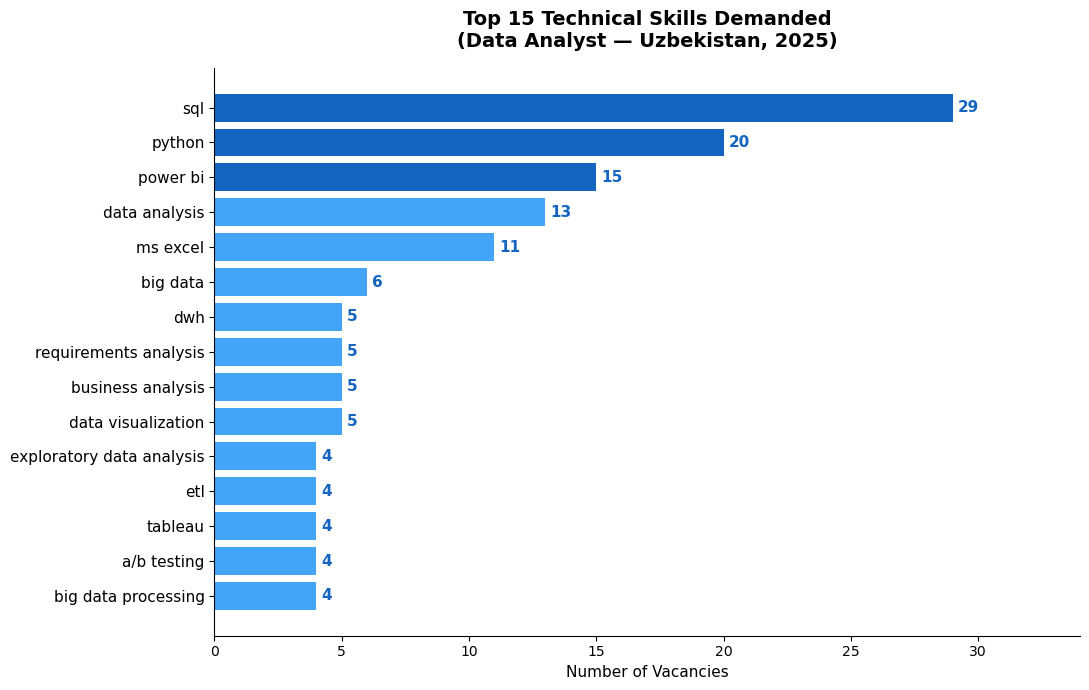

✅ top_skills.png saqlandi


In [11]:
fig, ax = plt.subplots(figsize=(11, 7))

top_skills = (
    df_vs_clean
    .merge(df_skills_clean, left_on="skill_id", right_on="id")
    .query("skill_type == 'Technical'")
    .groupby("name")["h_id"].count()
    .sort_values(ascending=False)
    .head(15)
)

colors = ["#1565C0" if i < 3 else "#42A5F5" for i in range(len(top_skills))]
bars = ax.barh(top_skills.index[::-1], top_skills.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top_skills.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=11, fontweight="bold", color="#1565C0")

ax.set_title("Top 15 Technical Skills Demanded\n(Data Analyst — Uzbekistan, 2025)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Vacancies", fontsize=11)
ax.set_xlim(0, top_skills.max() + 5)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=11)
plt.tight_layout()
plt.savefig("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/top_skills.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ top_skills.png saqlandi")

### Vacancy distribution by Category

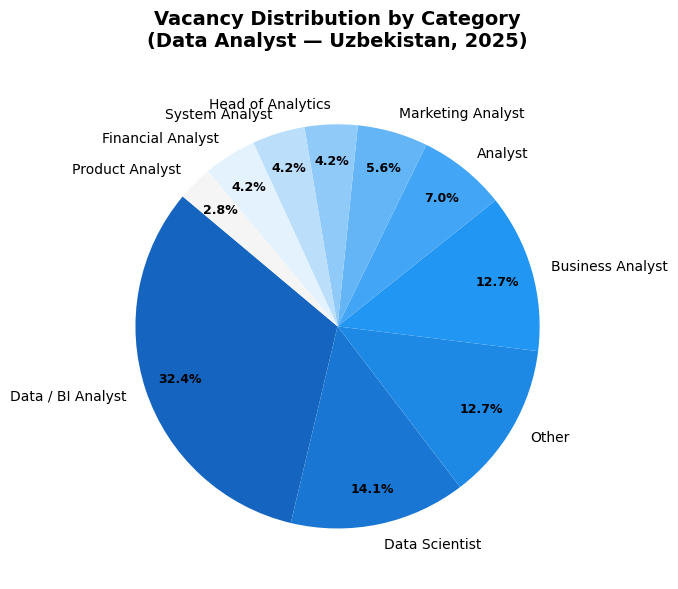

✅ category_distribution.png saqlandi


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

cat_counts = df_clean["category_en"].value_counts()

colors = ["#1565C0", "#1976D2", "#1E88E5", "#2196F3", "#42A5F5",
          "#64B5F6", "#90CAF9", "#BBDEFB", "#E3F2FD", "#F5F5F5"]

wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    colors=colors[:len(cat_counts)],
    startangle=140,
    pctdistance=0.82,
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

ax.set_title("Vacancy Distribution by Category\n(Data Analyst — Uzbekistan, 2025)",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/category_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ category_distribution.png saqlandi")

### Daily Vacancy Posting

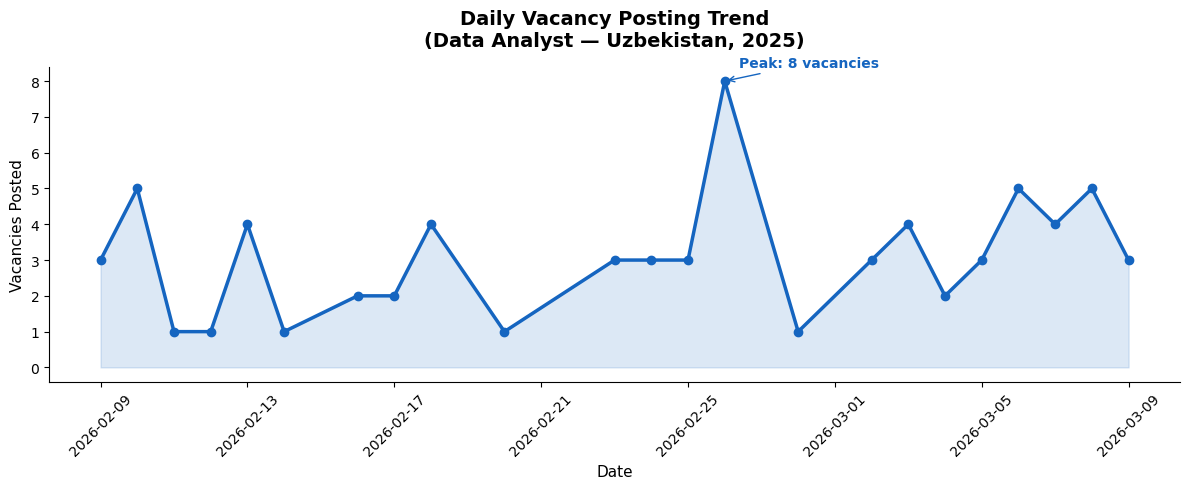

✅ daily_trend.png saqlandi


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

daily = (
    df_clean.groupby(df_clean["publish_date"].dt.date)
    .size()
    .reset_index(name="count")
)

ax.fill_between(daily["publish_date"], daily["count"], alpha=0.15, color="#1565C0")
ax.plot(daily["publish_date"], daily["count"], 
        color="#1565C0", linewidth=2.5, marker="o", markersize=6)

# Eng yuqori kun belgilash
peak = daily.loc[daily["count"].idxmax()]
ax.annotate(f'Peak: {peak["count"]} vacancies',
            xy=(peak["publish_date"], peak["count"]),
            xytext=(10, 10), textcoords="offset points",
            fontsize=10, color="#1565C0", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#1565C0"))

ax.set_title("Daily Vacancy Posting Trend\n(Data Analyst — Uzbekistan, 2025)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Vacancies Posted", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/daily_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ daily_trend.png saqlandi")

### Top 10 Companies

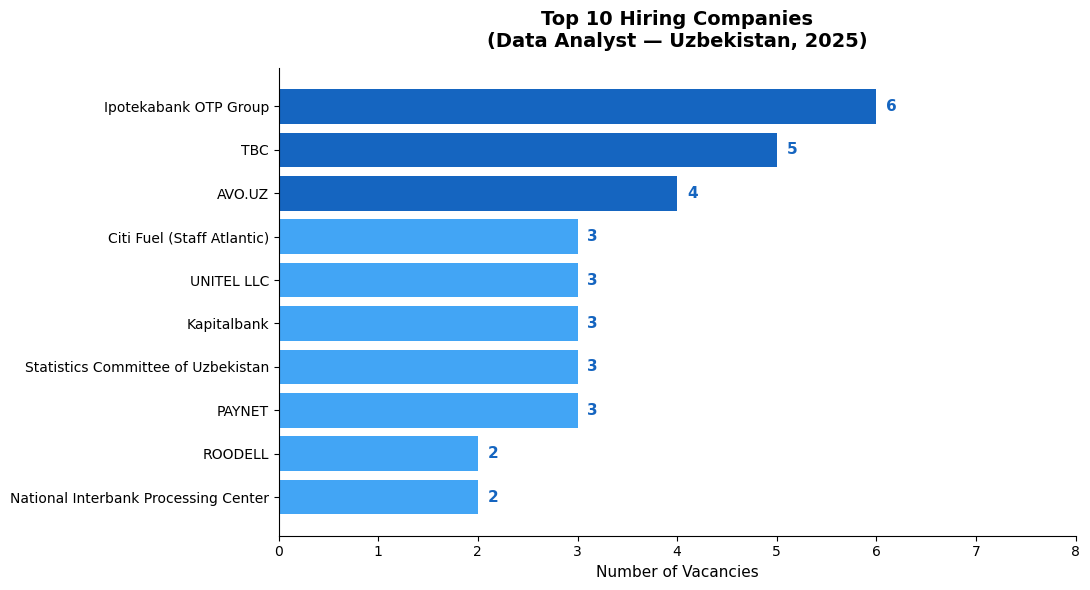

✅ top_companies.png saqlandi


In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

top_companies = df_clean["company"].value_counts().head(10)
colors = ["#1565C0" if i < 3 else "#42A5F5" for i in range(len(top_companies))]
bars = ax.barh(top_companies.index[::-1], top_companies.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top_companies.values[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=11, fontweight="bold", color="#1565C0")

ax.set_title("Top 10 Hiring Companies\n(Data Analyst — Uzbekistan, 2025)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Number of Vacancies", fontsize=11)
ax.set_xlim(0, top_companies.max() + 2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/top_companies.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ top_companies.png saqlandi")

### Skill Type breakdown

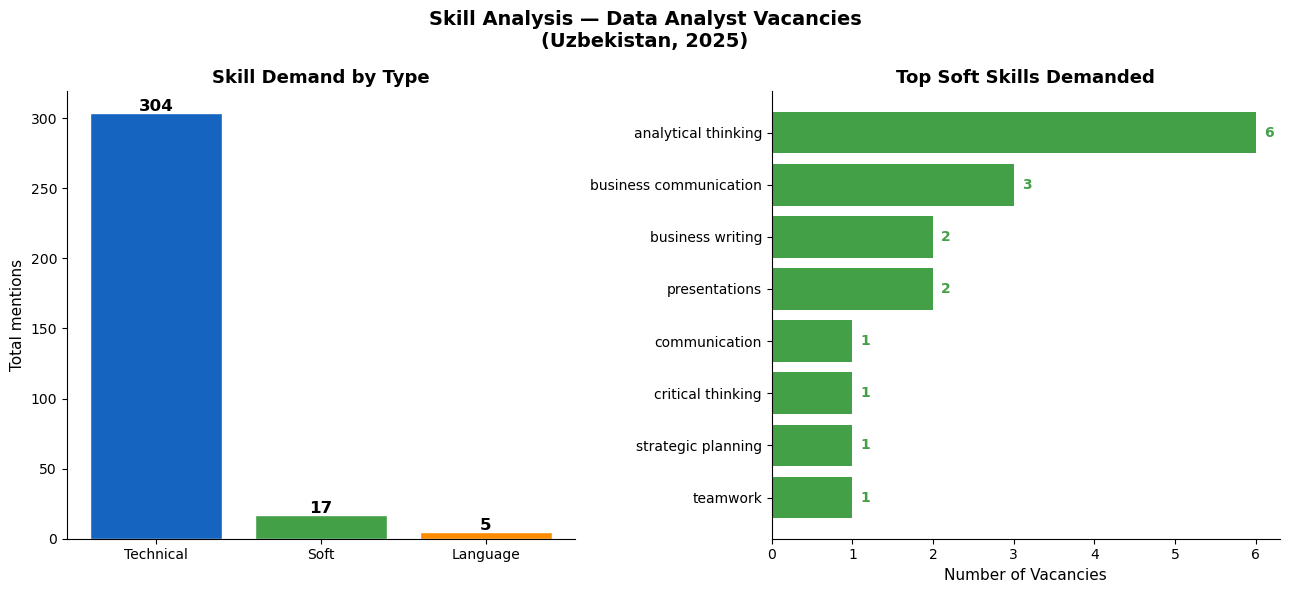

✅ skill_analysis.png saqlandi


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Skill type umumiy taqsimot
skill_type_counts = (
    df_vs_clean
    .merge(df_skills_clean, left_on="skill_id", right_on="id")
    .groupby("skill_type")["h_id"].count()
    .sort_values(ascending=False)
)

colors_type = {"Technical": "#1565C0", "Soft": "#43A047", "Language": "#FB8C00"}
axes[0].bar(skill_type_counts.index, skill_type_counts.values,
            color=[colors_type.get(t, "#90CAF9") for t in skill_type_counts.index],
            edgecolor="white")
for i, val in enumerate(skill_type_counts.values):
    axes[0].text(i, val + 1, str(val), ha="center", fontsize=12, fontweight="bold")

axes[0].set_title("Skill Demand by Type", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Total mentions", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

# Top soft skills
top_soft = (
    df_vs_clean
    .merge(df_skills_clean, left_on="skill_id", right_on="id")
    .query("skill_type == 'Soft'")
    .groupby("name")["h_id"].count()
    .sort_values(ascending=False)
    .head(8)
)
bars = axes[1].barh(top_soft.index[::-1], top_soft.values[::-1], color="#43A047")
for bar, val in zip(bars, top_soft.values[::-1]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=10, fontweight="bold", color="#43A047")

axes[1].set_title("Top Soft Skills Demanded", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Vacancies", fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Skill Analysis — Data Analyst Vacancies\n(Uzbekistan, 2025)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/skill_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ skill_analysis.png saqlandi")

### Salary insight

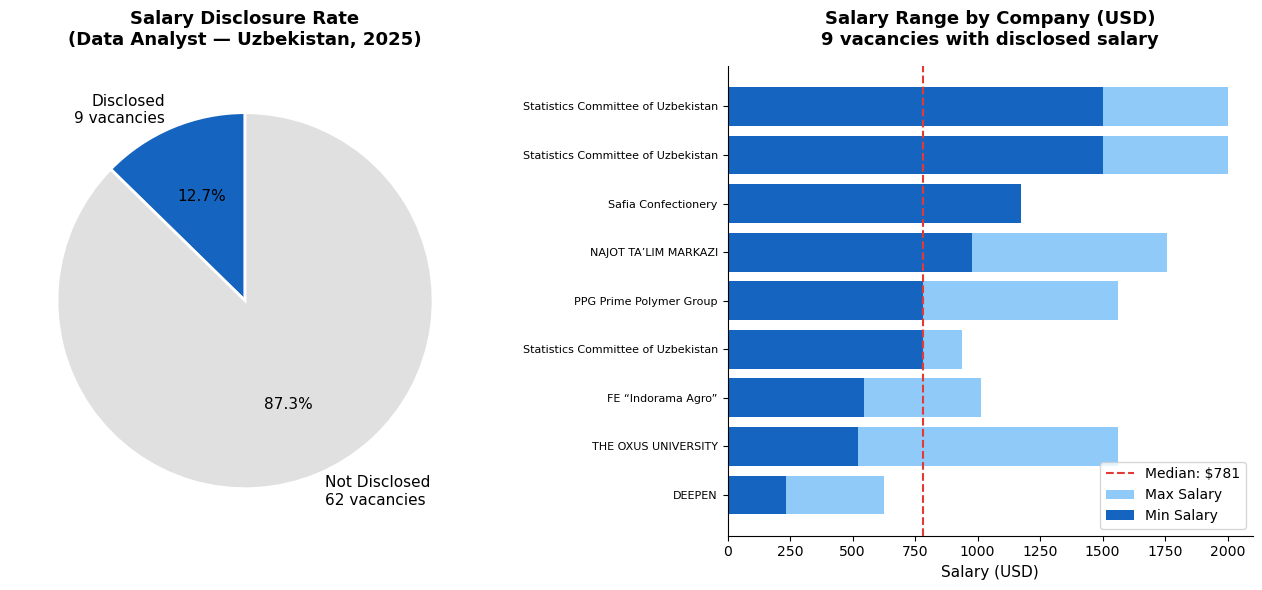

✅ salary_insights.png saqlandi

Median min salary : $781
Median max salary : $1562
Salary range      : $234 — $2000


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── 1. Maosh oshkoraligi (Salary Disclosure Rate) ──────────
total = len(df_clean)
disclosed = df_clean["min_salary_usd"].notna().sum()
not_disclosed = total - disclosed

axes[0].pie(
    [disclosed, not_disclosed],
    labels=[f"Disclosed\n{disclosed} vacancies", f"Not Disclosed\n{not_disclosed} vacancies"],
    colors=["#1565C0", "#E0E0E0"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)
axes[0].set_title("Salary Disclosure Rate\n(Data Analyst — Uzbekistan, 2025)",
                  fontsize=13, fontweight="bold", pad=15)

# ── 2. Maosh ko'rsatgan vacancylar — oddiy bar ─────────────
sal_df = (
    df_clean[df_clean["min_salary_usd"].notna()]
    [["company", "category_en", "min_salary_usd", "max_salary_usd", "salary_range_usd"]]
    .sort_values("min_salary_usd", ascending=True)
    .reset_index(drop=True)
)

y = range(len(sal_df))
axes[1].barh(y, sal_df["max_salary_usd"].fillna(sal_df["min_salary_usd"]),
             color="#90CAF9", label="Max Salary")
axes[1].barh(y, sal_df["min_salary_usd"],
             color="#1565C0", label="Min Salary")

axes[1].set_yticks(y)
axes[1].set_yticklabels(sal_df["company"], fontsize=8)
axes[1].set_xlabel("Salary (USD)", fontsize=11)
axes[1].set_title(f"Salary Range by Company (USD)\n{disclosed} vacancies with disclosed salary",
                  fontsize=13, fontweight="bold", pad=15)
axes[1].legend(fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)

# Median chiziq
median_val = sal_df["min_salary_usd"].median()
axes[1].axvline(median_val, color="#E53935", linestyle="--",
                linewidth=1.5, label=f"Median: ${median_val:.0f}")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/salary_insights.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ salary_insights.png saqlandi")
print(f"\nMedian min salary : ${sal_df['min_salary_usd'].median():.0f}")
print(f"Median max salary : ${sal_df['max_salary_usd'].median():.0f}")
print(f"Salary range      : ${sal_df['min_salary_usd'].min():.0f} — ${sal_df['max_salary_usd'].max():.0f}")

### Saving cleaned data

In [19]:
# Tozalangan ma'lumotlarni saqlash
df_clean.to_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_vacancies_clean.csv", index=False, encoding="utf-8-sig")
df_skills_clean.to_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_skills_clean.csv", index=False, encoding="utf-8-sig")
df_vs_clean.to_csv("C:/Users/Shoafzal/Desktop/HeadHunter-Vacancy-Collector/output/hh_vacancy_skill_clean.csv", index=False, encoding="utf-8-sig")

print("✅ Tozalangan CSV lar saqlandi!")
print(f"   hh_vacancies_clean.csv     → {len(df_clean)} qator")
print(f"   hh_skills_clean.csv        → {len(df_skills_clean)} qator")
print(f"   hh_vacancy_skill_clean.csv → {len(df_vs_clean)} qator")

✅ Tozalangan CSV lar saqlandi!
   hh_vacancies_clean.csv     → 71 qator
   hh_skills_clean.csv        → 157 qator
   hh_vacancy_skill_clean.csv → 326 qator
